# CSE440 Final Project 

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk gensim wordcloud tensorflow



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\MUJAHIDUL HAQUE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1) Imports and Setup

In [2]:
!pip install -q gensim wordcloud tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\MUJAHIDUL HAQUE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
# If needed, uncomment to install dependencies
# !pip install -q pandas numpy scikit-learn matplotlib seaborn nltk gensim wordcloud tensorflow

import re
import html
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from gensim.models import Word2Vec


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg)

[nltk_data] Downloading package punkt to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Zip Slip blocked: punkt/
[nltk_data] Downloading package stopwords to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Zip Slip blocked: stopwords/
[nltk_data] Downloading package wordnet to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [6]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg)

[nltk_data] Downloading package punkt to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Zip Slip blocked: punkt_tab/
[nltk_data] Downloading package stopwords to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MUJAHIDUL
[nltk_data]     HAQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2) Load Dataset

In [9]:
TRAIN_PATH = 'Training_data_9.csv'
TEST_PATH = 'Test_data.csv'

train_df = pd.read_csv('D:\My Projects\CSE440/Training_data_9.csv')
test_df = pd.read_csv('D:\My Projects\CSE440/Test_data.csv')

train_df = train_df.rename(columns={'News Headline': 'text', 'News Topic': 'label'})
test_df = test_df.rename(columns={'News Headline': 'text', 'News Topic': 'label'})

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('\nLabel distribution in train:')
print(train_df['label'].value_counts())

train_df.head()

Train shape: (88829, 2)
Test shape: (12000, 2)

Label distribution in train:
label
Sports                    35668
World News                31613
Business                  11801
Science and Technology     9747
Name: count, dtype: int64


,text,label
0,<html> <body> News Headlines:\n <br> <b> Jacks...,Sports
1,<html> <body> News Headlines:\n <br> <b> Howar...,World News
2,<html> <body> News Headlines:\n <br> <b> WinXP...,Science and Technology
3,<html> <body> News Headlines:\n <br> <b> Chief...,Sports
4,<html> <body> News Headlines:\n <br> <b> Poll ...,World News


## 3) EDA

,clean_eda,label,char_len,word_len
0,News Headlines: Jackson second to Leslie for M...,Sports,253,45
1,News Headlines: Howard plans regional spy scho...,World News,181,28
2,News Headlines: WinXP SP2 Home Edition To Be A...,Science and Technology,255,42


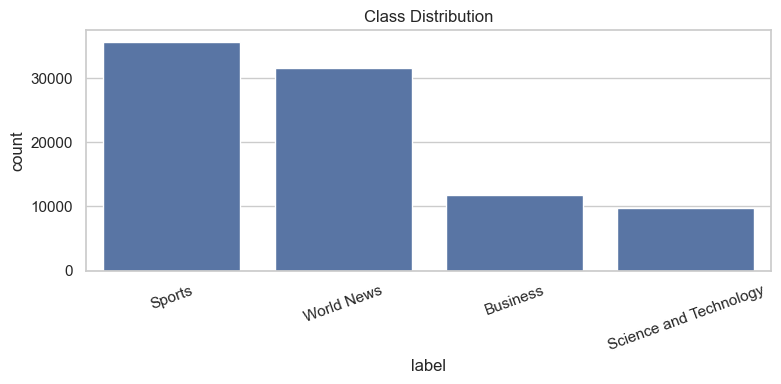

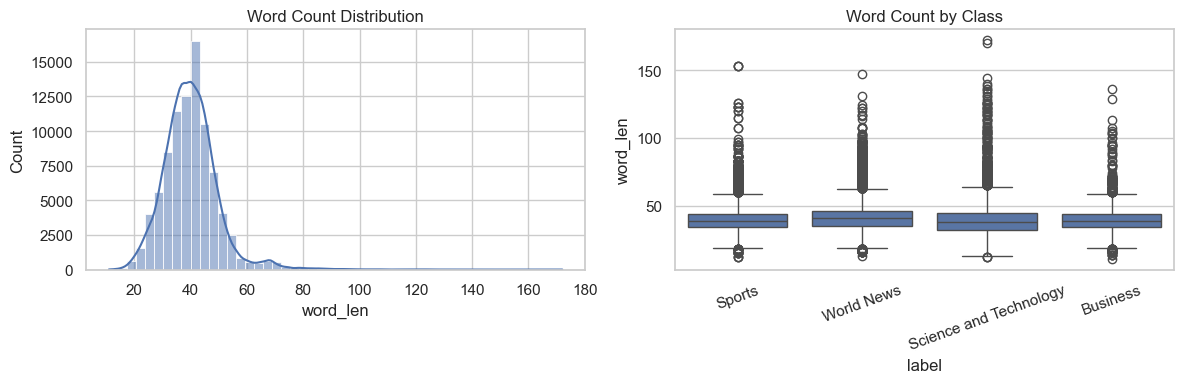

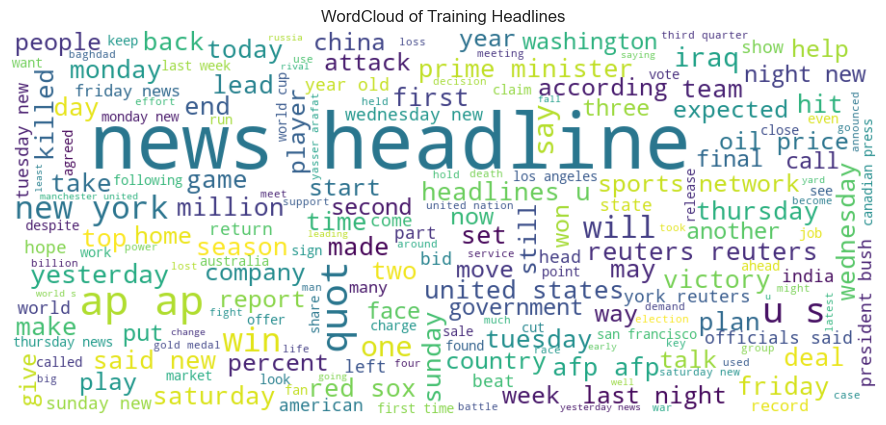

,token,count
0,the,158735
1,news,90486
2,headlines:,88831
3,to,86599
4,a,81468
5,in,76294
6,of,71717
7,and,49720
8,on,41689
9,for,37149


In [10]:
def strip_html_noise(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

eda_df = train_df.copy()
eda_df['clean_eda'] = eda_df['text'].apply(strip_html_noise)
eda_df['char_len'] = eda_df['clean_eda'].str.len()
eda_df['word_len'] = eda_df['clean_eda'].str.split().str.len()

display(eda_df[['clean_eda', 'label', 'char_len', 'word_len']].head(3))

plt.figure(figsize=(8, 4))
sns.countplot(data=eda_df, x='label', order=eda_df['label'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_df['word_len'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Word Count Distribution')
sns.boxplot(data=eda_df, x='label', y='word_len', ax=ax[1])
ax[1].set_title('Word Count by Class')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

all_text = ' '.join(eda_df['clean_eda']).lower()
wc = WordCloud(width=900, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Training Headlines')
plt.show()

top_tokens = Counter(all_text.split()).most_common(30)
pd.DataFrame(top_tokens, columns=['token', 'count'])

## 4) Build Three Preprocessing Variants

- **No preprocessing**: raw headlines
- **Extreme preprocessing**: HTML removal, lowercase, punctuation removal, stopwords removal, lemmatization, stemming
- **Optimum preprocessing**: moderate cleaning based on EDA, keeps negation terms for sentiment/context preservation

In [12]:
STOPWORDS = set(stopwords.words('english'))
NEGATION_KEEP = {'no', 'not', 'nor'}
STOPWORDS_OPTIMUM = STOPWORDS - NEGATION_KEEP
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_none(text):
    return str(text)

def normalize_text(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

def preprocess_extreme(text):
    text = normalize_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

def preprocess_optimum(text):
    text = normalize_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS_OPTIMUM and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

PREPROCESSORS = {
    'none': preprocess_none,
    'extreme': preprocess_extreme,
    'optimum': preprocess_optimum
}

## 5) Split Data + Encode Labels

In [13]:
# Set FAST_MODE=True for debugging only, False for final report runs
FAST_MODE = False
FAST_SAMPLES_PER_CLASS = 2500

work_train = train_df.copy()
work_test = test_df.copy()

if FAST_MODE:
    work_train = work_train.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), FAST_SAMPLES_PER_CLASS), random_state=SEED)).reset_index(drop=True)
    work_test = work_test.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), max(700, FAST_SAMPLES_PER_CLASS // 2)), random_state=SEED)).reset_index(drop=True)

train_part, val_part = train_test_split(
    work_train,
    test_size=0.15,
    random_state=SEED,
    stratify=work_train['label']
)

label_encoder = LabelEncoder()
label_encoder.fit(work_train['label'])

y_train = label_encoder.transform(train_part['label'])
y_val = label_encoder.transform(val_part['label'])
y_test = label_encoder.transform(work_test['label'])

num_classes = len(label_encoder.classes_)

y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh = to_categorical(y_val, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

print('Train split:', train_part.shape)
print('Val split:', val_part.shape)
print('Test split:', work_test.shape)
print('Classes:', list(label_encoder.classes_))

Train split: (75504, 2)
Val split: (13325, 2)
Test split: (12000, 2)
Classes: ['Business', 'Science and Technology', 'Sports', 'World News']


## 6) Shared Utility Functions

In [14]:
all_results = []
tuning_logs = []

def get_preprocessed_splits(prep_fn):
    X_train_text = train_part['text'].apply(prep_fn).astype(str).values
    X_val_text = val_part['text'].apply(prep_fn).astype(str).values
    X_test_text = work_test['text'].apply(prep_fn).astype(str).values
    return X_train_text, X_val_text, X_test_text

def evaluate_and_store(y_true, y_pred, prep_name, rep_name, model_name):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n[{prep_name} | {rep_name} | {model_name}]')
    print(f'Accuracy: {acc:.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    print('Classification report:')
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {prep_name} | {rep_name} | {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    all_results.append({
        'preprocessing': prep_name,
        'representation': rep_name,
        'model': model_name,
        'accuracy': acc,
        'macro_f1': macro_f1
    })

def add_tuning_log(prep, rep, model, config, val_f1):
    tuning_logs.append({
        'preprocessing': prep,
        'representation': rep,
        'model': model,
        'config': str(config),
        'val_macro_f1': float(val_f1)
    })

## 7) TF-IDF + Logistic Regression (ML) + Deep NN (Keras)


TF-IDF experiments for preprocessing: none
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8954
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8990
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9007
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8852
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8906
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8916
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val

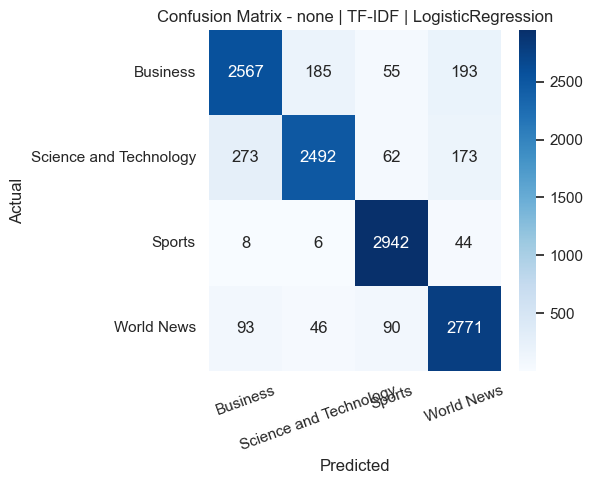

Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.9020 - loss: 0.2850 - val_accuracy: 0.9413 - val_loss: 0.1823
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.9583 - loss: 0.1258 - val_accuracy: 0.9473 - val_loss: 0.1763
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.9761 - loss: 0.0725 - val_accuracy: 0.9475 - val_loss: 0.1937
Epoch 4/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9865 - loss: 0.0411 - val_accuracy: 0.9498 - val_loss: 0.2224
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 8, 'lr': 0.001} -> val_macro_f1=0.9199
Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.8921 - loss: 0.3061 - val_accuracy: 0.9394 - val_loss: 0.1887
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9524 - loss: 0.1462 - val_accuracy: 0.9459 - val_loss: 0.1720
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9688 - loss: 0.0963 -

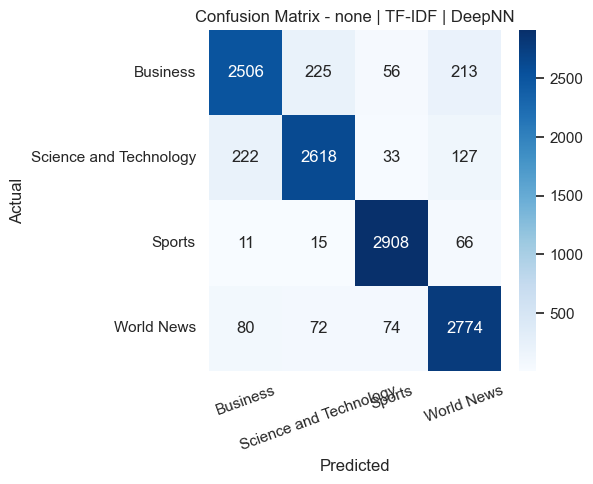


TF-IDF experiments for preprocessing: extreme
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8980
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9004
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9019
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8966
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9011
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9038
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> 

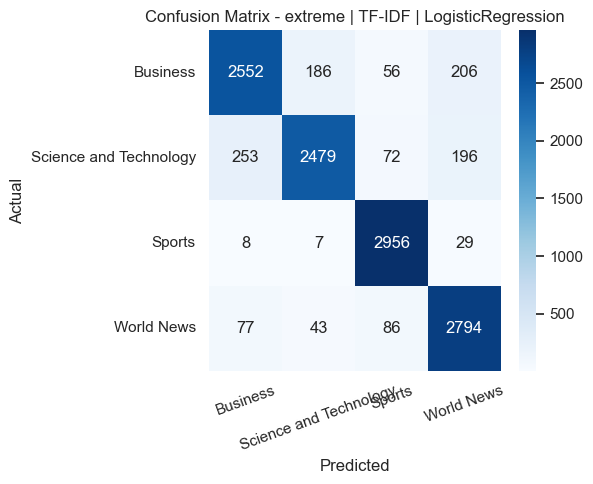

Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.9052 - loss: 0.2779 - val_accuracy: 0.9389 - val_loss: 0.1813
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9549 - loss: 0.1317 - val_accuracy: 0.9442 - val_loss: 0.1767
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9738 - loss: 0.0796 - val_accuracy: 0.9456 - val_loss: 0.1983
Epoch 4/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9838 - loss: 0.0473 - val_accuracy: 0.9472 - val_loss: 0.2298
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 8, 'lr': 0.001} -> val_macro_f1=0.9149
Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.8963 - loss: 0.2992 - val_accuracy: 0.9377 - val_loss: 0.1865
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.9509 - loss: 0.1493 - val_accuracy: 0.9449 - val_loss: 0.1713
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9655 - loss: 0.1036 -

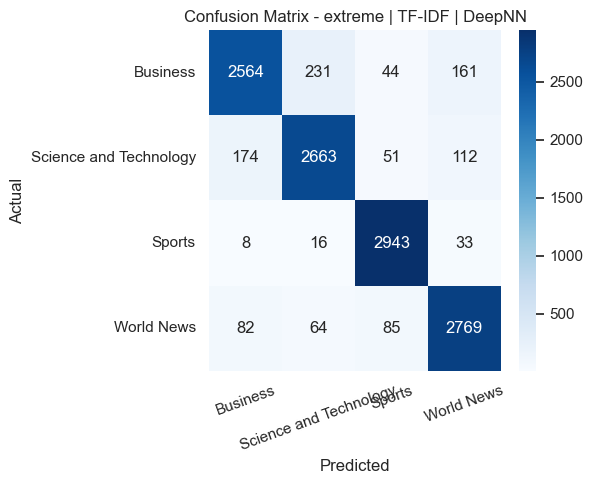


TF-IDF experiments for preprocessing: optimum
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8969
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8996
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9014
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8943
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9001
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9011
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> 

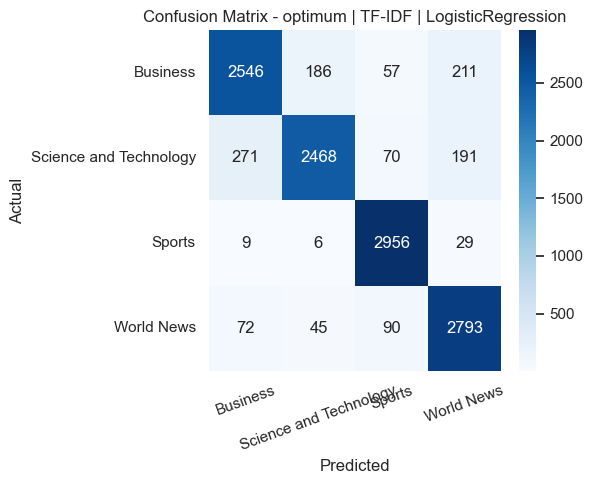

Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.9023 - loss: 0.2803 - val_accuracy: 0.9385 - val_loss: 0.1866
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.9567 - loss: 0.1308 - val_accuracy: 0.9439 - val_loss: 0.1777
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - accuracy: 0.9736 - loss: 0.0780 - val_accuracy: 0.9468 - val_loss: 0.2009
Epoch 4/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9839 - loss: 0.0463 - val_accuracy: 0.9450 - val_loss: 0.2442
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 8, 'lr': 0.001} -> val_macro_f1=0.9146
Epoch 1/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.8964 - loss: 0.2997 - val_accuracy: 0.9381 - val_loss: 0.1864
Epoch 2/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9514 - loss: 0.1494 - val_accuracy: 0.9446 - val_loss: 0.1739
Epoch 3/8
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9665 - loss: 0.1016 -

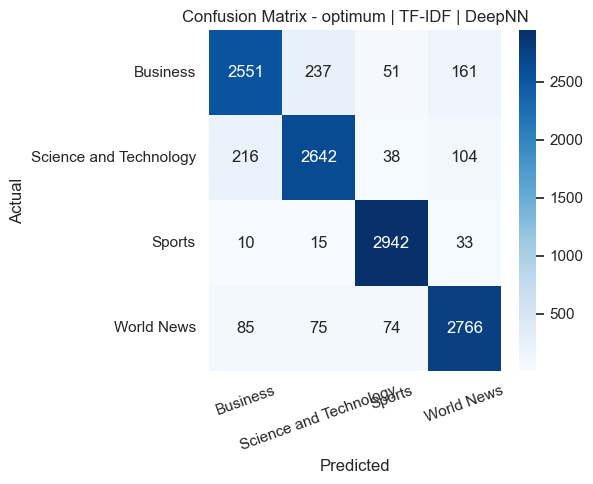

In [15]:
def build_tfidf_dnn(input_dim, num_classes, dense1=256, dense2=128, drop=0.5, lr=1e-3):
    model = Sequential([
        Dense(dense1, activation='relu', input_shape=(input_dim,)),
        Dropout(drop),
        Dense(dense2, activation='relu'),
        Dropout(drop),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tfidf_grid = {
    'max_features': [5000, 8000],
    'ngram_range': [(1, 1), (1, 2)],
    'min_df': [2]
}

lr_grid = {
    'C': [0.5, 1.0, 2.0],
    'solver': ['lbfgs'],
    'max_iter': [400]
}

dnn_grid = {
    'dense1': [256, 384],
    'dense2': [128, 192],
    'drop': [0.35, 0.5],
    'lr': [1e-3],
    'batch_size': [64],
    'epochs': [8]
}

for prep_name, prep_fn in PREPROCESSORS.items():
    print('\n' + '=' * 95)
    print('TF-IDF experiments for preprocessing:', prep_name)

    X_train_text, X_val_text, X_test_text = get_preprocessed_splits(prep_fn)

    best_lr_f1 = -1
    best_lr_model = None
    best_vectorizer = None

    for tfcfg in ParameterGrid(tfidf_grid):
        vectorizer = TfidfVectorizer(**tfcfg)
        X_tr = vectorizer.fit_transform(X_train_text)
        X_va = vectorizer.transform(X_val_text)

        for lrcfg in ParameterGrid(lr_grid):
            lr_model = LogisticRegression(random_state=SEED, **lrcfg)
            lr_model.fit(X_tr, y_train)
            val_pred = lr_model.predict(X_va)
            val_f1 = f1_score(y_val, val_pred, average='macro')
            add_tuning_log(prep_name, 'TF-IDF', 'LogisticRegression', {**tfcfg, **lrcfg}, val_f1)
            print(f'LR cfg: {tfcfg} + {lrcfg} -> val_macro_f1={val_f1:.4f}')
            if val_f1 > best_lr_f1:
                best_lr_f1 = val_f1
                best_lr_model = lr_model
                best_vectorizer = vectorizer

    X_te = best_vectorizer.transform(X_test_text)
    test_pred_lr = best_lr_model.predict(X_te)
    evaluate_and_store(y_test, test_pred_lr, prep_name, 'TF-IDF', 'LogisticRegression')

    X_tr_dense = best_vectorizer.fit_transform(X_train_text).toarray().astype(np.float32)
    X_va_dense = best_vectorizer.transform(X_val_text).toarray().astype(np.float32)
    X_te_dense = best_vectorizer.transform(X_test_text).toarray().astype(np.float32)

    best_dnn_f1 = -1
    best_dnn_model = None
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for dcfg in ParameterGrid(dnn_grid):
        dnn = build_tfidf_dnn(
            input_dim=X_tr_dense.shape[1],
            num_classes=num_classes,
            dense1=dcfg['dense1'],
            dense2=dcfg['dense2'],
            drop=dcfg['drop'],
            lr=dcfg['lr']
        )
        dnn.fit(
            X_tr_dense, y_train_oh,
            validation_data=(X_va_dense, y_val_oh),
            epochs=dcfg['epochs'],
            batch_size=dcfg['batch_size'],
            verbose=1,
            callbacks=[early_stop]
        )
        val_pred = np.argmax(dnn.predict(X_va_dense, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_pred, average='macro')
        add_tuning_log(prep_name, 'TF-IDF', 'DeepNN', dcfg, val_f1)
        print(f'DeepNN cfg: {dcfg} -> val_macro_f1={val_f1:.4f}')
        if val_f1 > best_dnn_f1:
            best_dnn_f1 = val_f1
            best_dnn_model = dnn

    test_pred_dnn = np.argmax(best_dnn_model.predict(X_te_dense, verbose=0), axis=1)
    evaluate_and_store(y_test, test_pred_dnn, prep_name, 'TF-IDF', 'DeepNN')

## 8) Skip-gram + All Required Sequence Models


Skip-gram experiments for preprocessing: none
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4700 - loss: 1.1899 - val_accuracy: 0.4252 - val_loss: 1.2404
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4185 - loss: 1.2349 - val_accuracy: 0.3601 - val_loss: 1.2741
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4157 - loss: 1.2373 - val_accuracy: 0.4011 - val_loss: 1.2469
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.1899
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5384 - loss: 1.1110 - val_accuracy: 0.3886 - val_loss: 1.2582
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.6226 - loss: 0.9400 - val_accuracy: 0.7063 - val_loss: 0.7568
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.5969 - loss: 1.0078 - val_accuracy: 0.6995 - val_loss: 0.8023
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/

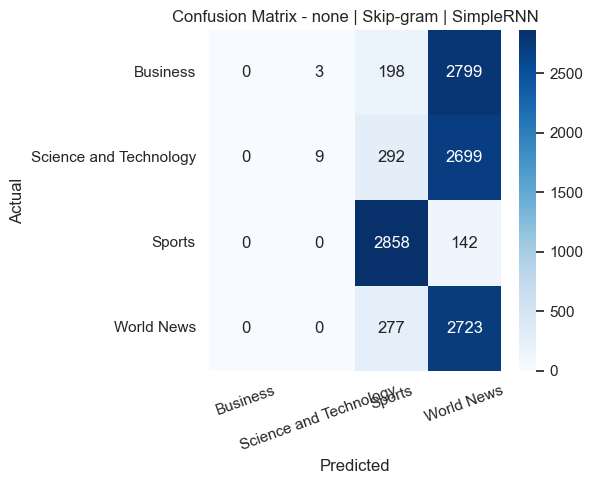

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.8076 - loss: 0.4990 - val_accuracy: 0.8873 - val_loss: 0.3257
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9028 - loss: 0.2921 - val_accuracy: 0.9068 - val_loss: 0.2697
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9161 - loss: 0.2491 - val_accuracy: 0.9160 - val_loss: 0.2429
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9257 - loss: 0.2237 - val_accuracy: 0.9228 - val_loss: 0.2215
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9303 - loss: 0.2041 - val_accuracy: 0.9253 - val_loss: 0.2111
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9357 - loss: 0.1876 - val_accuracy: 0.9294 - val_loss: 0.2035
GRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8953
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 73s 59ms/step - accuracy: 0.8213 - loss: 0.4691 - val_accuracy

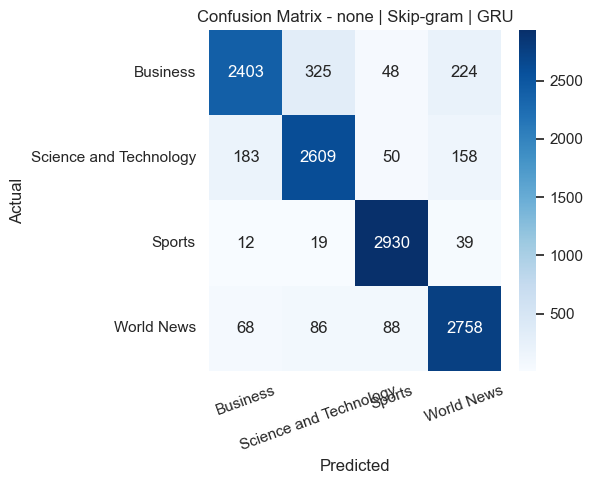

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.8433 - loss: 0.4457 - val_accuracy: 0.8691 - val_loss: 0.3752
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.8944 - loss: 0.3195 - val_accuracy: 0.8986 - val_loss: 0.2953
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.9088 - loss: 0.2757 - val_accuracy: 0.9037 - val_loss: 0.2747
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.9162 - loss: 0.2489 - val_accuracy: 0.9038 - val_loss: 0.2754
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9233 - loss: 0.2280 - val_accuracy: 0.9063 - val_loss: 0.2684
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9286 - loss: 0.2100 - val_accuracy: 0.9099 - val_loss: 0.2488
LSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8712
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 74s 58ms/step - accuracy: 0.8452 - loss: 0.4384 - val_accurac

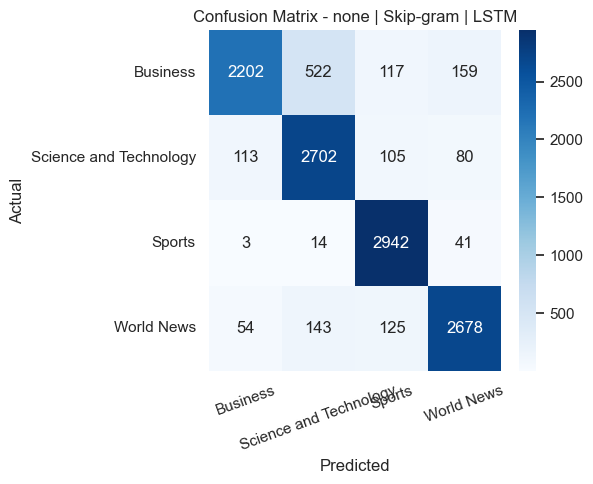

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.7378 - loss: 0.7033 - val_accuracy: 0.7877 - val_loss: 0.5844
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.8103 - loss: 0.5352 - val_accuracy: 0.8380 - val_loss: 0.4714
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.8342 - loss: 0.5009 - val_accuracy: 0.8055 - val_loss: 0.5749
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.8308 - loss: 0.5302 - val_accuracy: 0.8361 - val_loss: 0.4968
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.7634
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.6786 - loss: 0.8160 - val_accuracy: 0.6997 - val_loss: 0.8059
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7064 - loss: 0.7864 - val_accuracy: 0.7717 - val_loss: 0.6275
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 96}

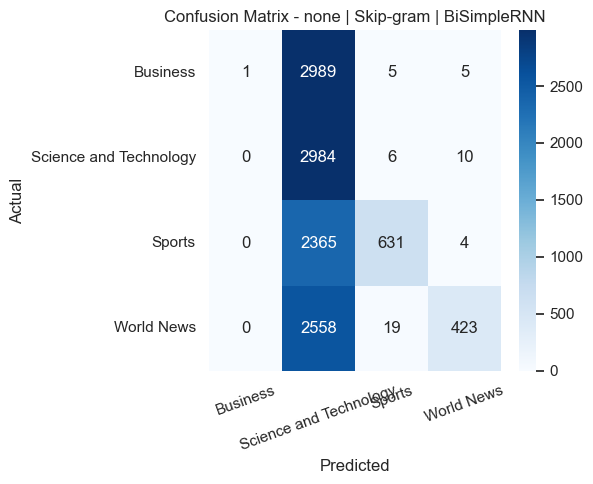

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.8291 - loss: 0.4542 - val_accuracy: 0.8919 - val_loss: 0.3120
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.9071 - loss: 0.2715 - val_accuracy: 0.9066 - val_loss: 0.2538
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - accuracy: 0.9196 - loss: 0.2290 - val_accuracy: 0.9165 - val_loss: 0.2425
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.9292 - loss: 0.2002 - val_accuracy: 0.9257 - val_loss: 0.2142
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step - accuracy: 0.9380 - loss: 0.1764 - val_accuracy: 0.9296 - val_loss: 0.2102
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 60s 51ms/step - accuracy: 0.9441 - loss: 0.1585 - val_accuracy: 0.9339 - val_loss: 0.2021
BiGRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8991
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.8427 - loss: 0.4287 - val_accura

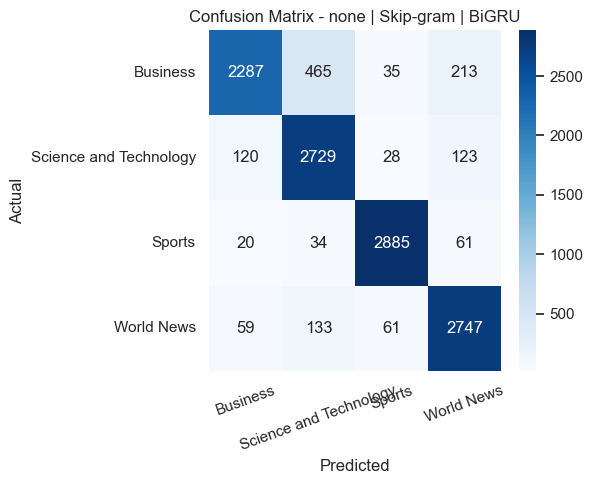

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.8596 - loss: 0.4024 - val_accuracy: 0.8882 - val_loss: 0.3189
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.9010 - loss: 0.2876 - val_accuracy: 0.9072 - val_loss: 0.2561
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9168 - loss: 0.2421 - val_accuracy: 0.9099 - val_loss: 0.2498
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9264 - loss: 0.2118 - val_accuracy: 0.9193 - val_loss: 0.2361
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - accuracy: 0.9340 - loss: 0.1886 - val_accuracy: 0.9226 - val_loss: 0.2285
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9418 - loss: 0.1697 - val_accuracy: 0.9269 - val_loss: 0.2179
BiLSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8917
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.8643 - loss: 0.3906 - val_accur

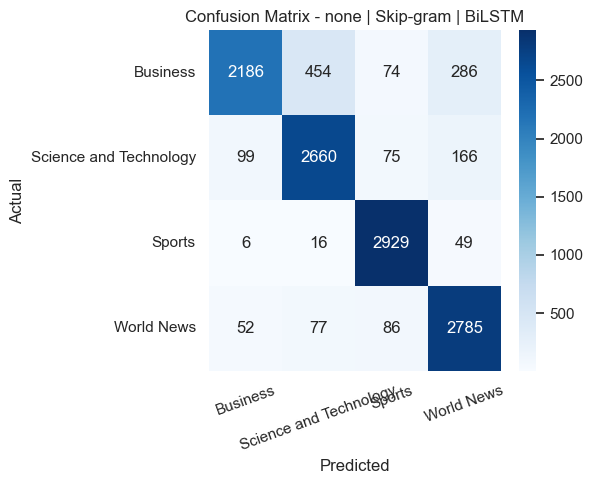


Skip-gram experiments for preprocessing: extreme
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7549 - loss: 0.6420 - val_accuracy: 0.8154 - val_loss: 0.4990
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.4879 - loss: 1.1034 - val_accuracy: 0.4016 - val_loss: 1.2513
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3939 - loss: 1.2493 - val_accuracy: 0.4016 - val_loss: 1.2501
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.6160
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4377 - loss: 1.1130 - val_accuracy: 0.4016 - val_loss: 1.2521
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.3968 - loss: 1.2390 - val_accuracy: 0.4016 - val_loss: 1.2550
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 96} -> val_macro_f1=0.1436
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accu

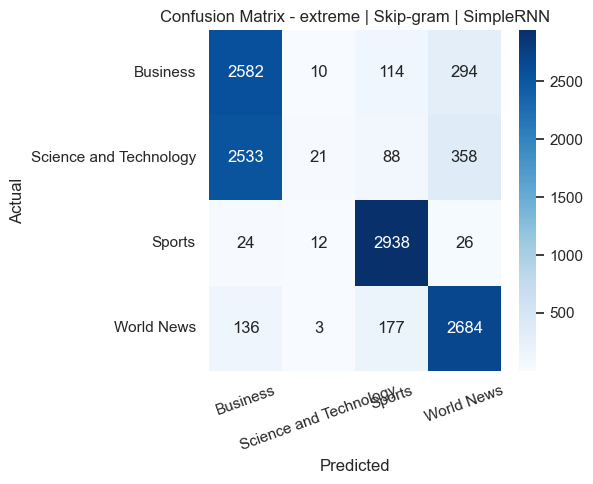

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.8124 - loss: 0.4709 - val_accuracy: 0.9175 - val_loss: 0.2542
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9205 - loss: 0.2449 - val_accuracy: 0.9241 - val_loss: 0.2231
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9272 - loss: 0.2213 - val_accuracy: 0.9277 - val_loss: 0.2093
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9322 - loss: 0.2037 - val_accuracy: 0.9312 - val_loss: 0.1983
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9368 - loss: 0.1886 - val_accuracy: 0.9346 - val_loss: 0.1885
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9414 - loss: 0.1740 - val_accuracy: 0.9373 - val_loss: 0.1845
GRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9047
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.7904 - loss: 0.5103 - val_accuracy

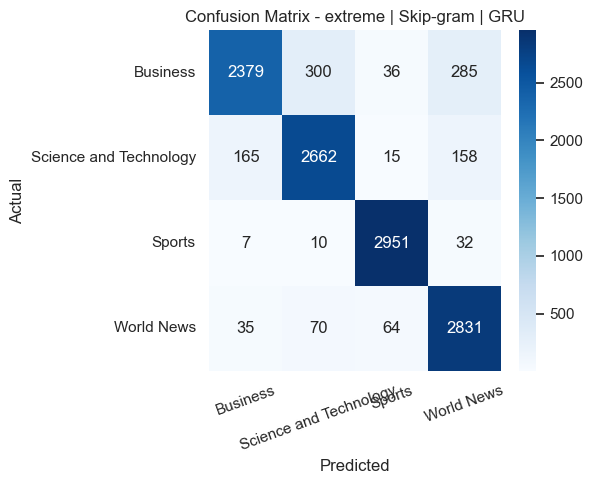

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.8111 - loss: 0.4578 - val_accuracy: 0.8997 - val_loss: 0.3040
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9056 - loss: 0.3055 - val_accuracy: 0.9186 - val_loss: 0.2629
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9180 - loss: 0.2607 - val_accuracy: 0.9229 - val_loss: 0.2403
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9241 - loss: 0.2394 - val_accuracy: 0.9261 - val_loss: 0.2284
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9279 - loss: 0.2222 - val_accuracy: 0.9285 - val_loss: 0.2215
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9306 - loss: 0.2101 - val_accuracy: 0.9302 - val_loss: 0.2117
LSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8960
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 62s 51ms/step - accuracy: 0.8099 - loss: 0.4597 - val_accurac

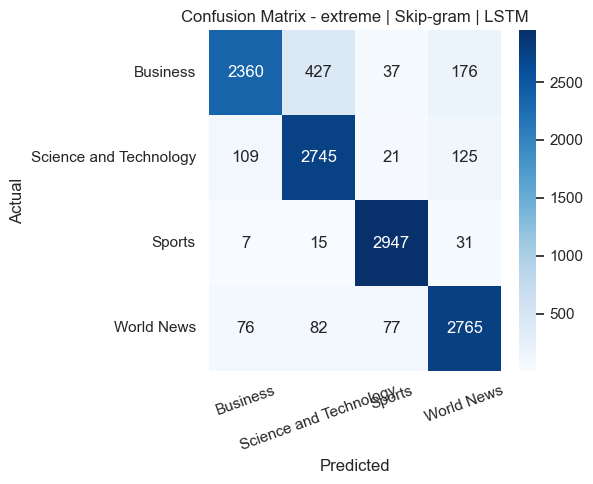

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.8760 - loss: 0.3772 - val_accuracy: 0.9023 - val_loss: 0.3038
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9041 - loss: 0.3010 - val_accuracy: 0.9069 - val_loss: 0.2916
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.9068 - loss: 0.2897 - val_accuracy: 0.9056 - val_loss: 0.2908
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9093 - loss: 0.2797 - val_accuracy: 0.9095 - val_loss: 0.2845
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9124 - loss: 0.2681 - val_accuracy: 0.9054 - val_loss: 0.2952
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9143 - loss: 0.2697 - val_accuracy: 0.9054 - val_loss: 0.2882
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8680
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.8825 - loss: 0.3581 - val_

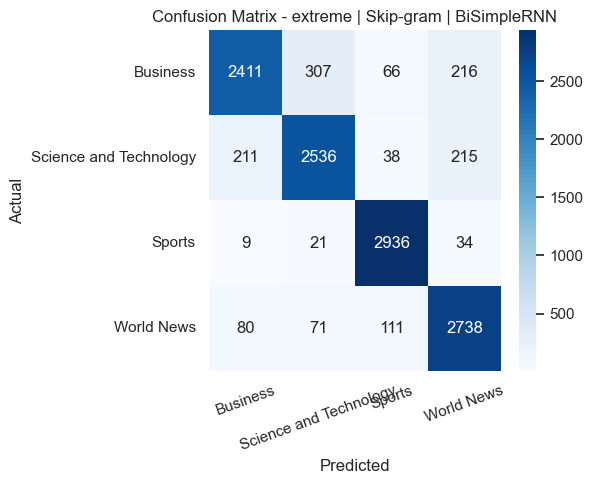

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.8952 - loss: 0.3059 - val_accuracy: 0.9197 - val_loss: 0.2311
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - accuracy: 0.9244 - loss: 0.2266 - val_accuracy: 0.9275 - val_loss: 0.2106
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - accuracy: 0.9309 - loss: 0.2061 - val_accuracy: 0.9325 - val_loss: 0.1954
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - accuracy: 0.9353 - loss: 0.1886 - val_accuracy: 0.9352 - val_loss: 0.1872
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - accuracy: 0.9404 - loss: 0.1723 - val_accuracy: 0.9364 - val_loss: 0.1839
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - accuracy: 0.9461 - loss: 0.1565 - val_accuracy: 0.9364 - val_loss: 0.1827
BiGRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9041
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 73s 59ms/step - accuracy: 0.9013 - loss: 0.2934 - val_accura

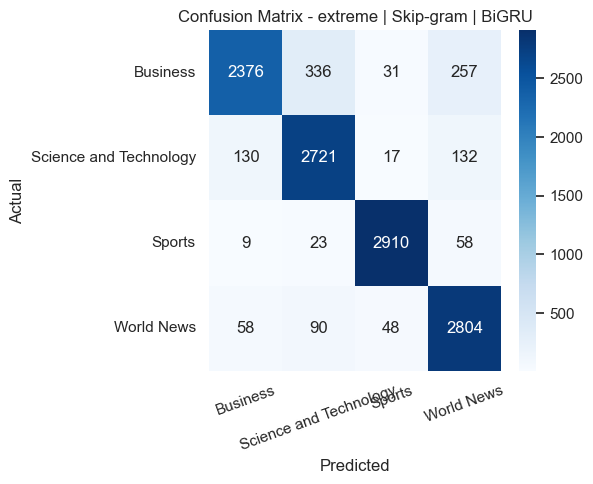

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.9020 - loss: 0.2935 - val_accuracy: 0.9154 - val_loss: 0.2446
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9222 - loss: 0.2319 - val_accuracy: 0.9242 - val_loss: 0.2162
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9302 - loss: 0.2078 - val_accuracy: 0.9305 - val_loss: 0.1983
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9359 - loss: 0.1898 - val_accuracy: 0.9325 - val_loss: 0.1947
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9399 - loss: 0.1749 - val_accuracy: 0.9370 - val_loss: 0.1822
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9456 - loss: 0.1603 - val_accuracy: 0.9378 - val_loss: 0.1796
BiLSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9064
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 99s 80ms/step - accuracy: 0.9032 - loss: 0.2872 - val_accur

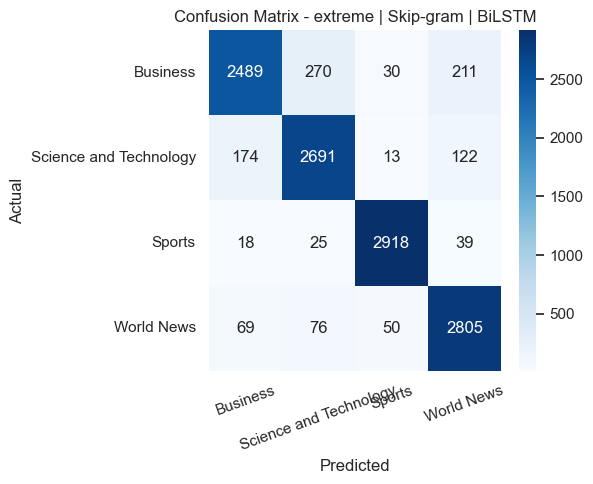


Skip-gram experiments for preprocessing: optimum
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5862 - loss: 1.0159 - val_accuracy: 0.7431 - val_loss: 0.6600
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5223 - loss: 1.0378 - val_accuracy: 0.4017 - val_loss: 1.2501
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.3927 - loss: 1.2483 - val_accuracy: 0.4027 - val_loss: 1.2486
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.5500
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.4879 - loss: 1.1615 - val_accuracy: 0.5890 - val_loss: 1.0594
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.6741 - loss: 0.8374 - val_accuracy: 0.5490 - val_loss: 1.2140
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 96} -> val_macro_f1=0.3344
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accu

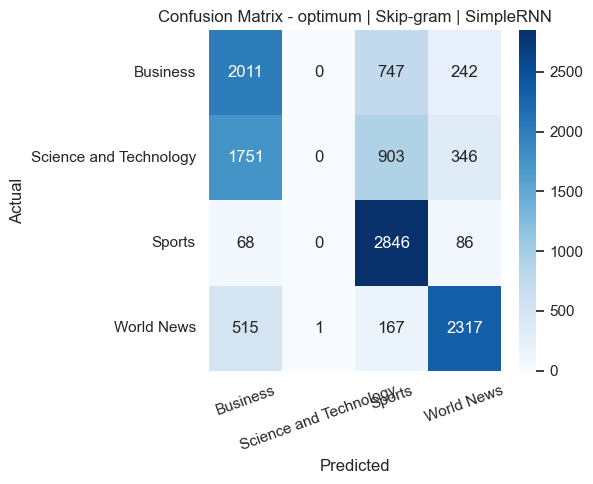

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7860 - loss: 0.5063 - val_accuracy: 0.9182 - val_loss: 0.2485
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9221 - loss: 0.2403 - val_accuracy: 0.9261 - val_loss: 0.2183
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step - accuracy: 0.9281 - loss: 0.2152 - val_accuracy: 0.9319 - val_loss: 0.1990
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.9331 - loss: 0.1976 - val_accuracy: 0.9344 - val_loss: 0.1884
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9377 - loss: 0.1837 - val_accuracy: 0.9353 - val_loss: 0.1851
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step - accuracy: 0.9421 - loss: 0.1705 - val_accuracy: 0.9382 - val_loss: 0.1817
GRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9070
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.7584 - loss: 0.5592 - val_accuracy

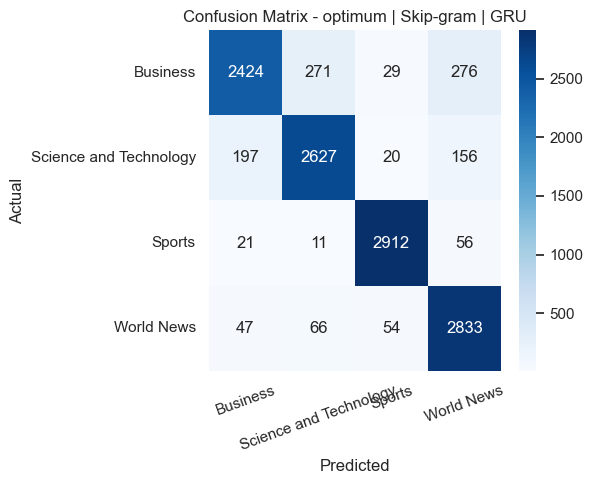

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.8657 - loss: 0.4045 - val_accuracy: 0.9036 - val_loss: 0.3075
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9163 - loss: 0.2662 - val_accuracy: 0.9188 - val_loss: 0.2514
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9235 - loss: 0.2378 - val_accuracy: 0.9220 - val_loss: 0.2363
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9287 - loss: 0.2180 - val_accuracy: 0.9288 - val_loss: 0.2223
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9338 - loss: 0.2014 - val_accuracy: 0.9262 - val_loss: 0.2222
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.9362 - loss: 0.1901 - val_accuracy: 0.9327 - val_loss: 0.2035
LSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9003
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 55s 45ms/step - accuracy: 0.8350 - loss: 0.4256 - val_accurac

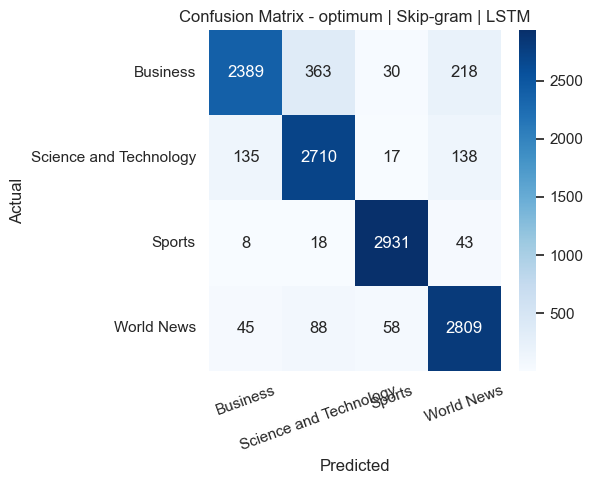

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.8839 - loss: 0.3568 - val_accuracy: 0.8881 - val_loss: 0.3229
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9058 - loss: 0.2957 - val_accuracy: 0.8997 - val_loss: 0.2929
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.9113 - loss: 0.2786 - val_accuracy: 0.8975 - val_loss: 0.3064
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9138 - loss: 0.2681 - val_accuracy: 0.8991 - val_loss: 0.3000
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8532
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8840 - loss: 0.3560 - val_accuracy: 0.8967 - val_loss: 0.3115
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.9045 - loss: 0.3004 - val_accuracy: 0.8907 - val_loss: 0.3291
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 96}

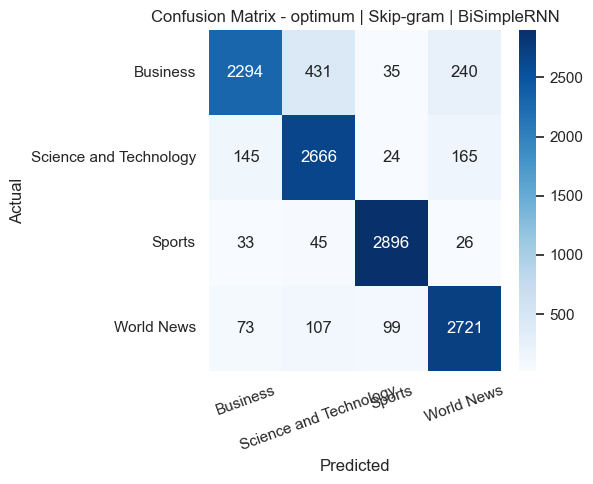

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.8973 - loss: 0.2995 - val_accuracy: 0.9204 - val_loss: 0.2282
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.9263 - loss: 0.2204 - val_accuracy: 0.9295 - val_loss: 0.2011
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - accuracy: 0.9315 - loss: 0.2000 - val_accuracy: 0.9352 - val_loss: 0.1852
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - accuracy: 0.9375 - loss: 0.1821 - val_accuracy: 0.9382 - val_loss: 0.1771
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - accuracy: 0.9420 - loss: 0.1679 - val_accuracy: 0.9417 - val_loss: 0.1709
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 51s 44ms/step - accuracy: 0.9469 - loss: 0.1543 - val_accuracy: 0.9415 - val_loss: 0.1680
BiGRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9100
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.9042 - loss: 0.2831 - val_accura

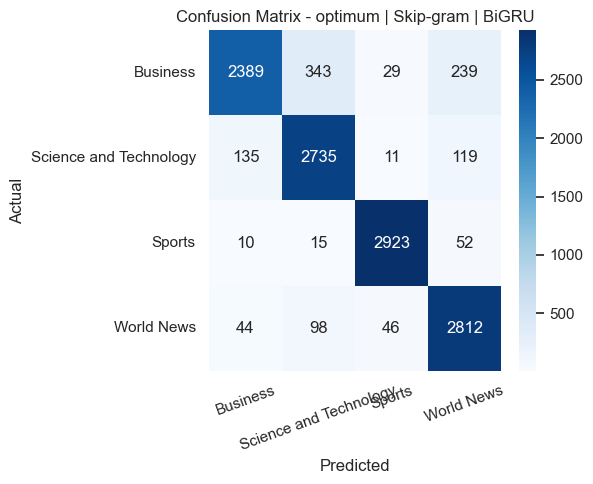

Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9008 - loss: 0.2941 - val_accuracy: 0.9148 - val_loss: 0.2407
Epoch 2/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9231 - loss: 0.2260 - val_accuracy: 0.9246 - val_loss: 0.2135
Epoch 3/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9302 - loss: 0.2028 - val_accuracy: 0.9289 - val_loss: 0.2035
Epoch 4/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9361 - loss: 0.1845 - val_accuracy: 0.9363 - val_loss: 0.1829
Epoch 5/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.9414 - loss: 0.1717 - val_accuracy: 0.9396 - val_loss: 0.1778
Epoch 6/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9452 - loss: 0.1595 - val_accuracy: 0.9412 - val_loss: 0.1713
BiLSTM cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 6, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.9107
Epoch 1/6
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 76s 62ms/step - accuracy: 0.9048 - loss: 0.2814 - val_accur

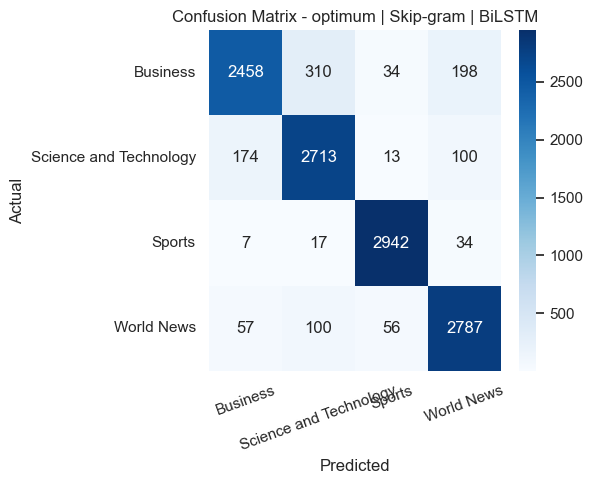

In [16]:
MAX_WORDS = 30000
MAX_LEN = 60
EMBED_DIM = 100

def build_embedding_matrix(word_index, w2v, max_words=MAX_WORDS, embed_dim=EMBED_DIM):
    vocab_size = min(max_words, len(word_index) + 1)
    emb_matrix = np.random.normal(scale=0.6, size=(vocab_size, embed_dim))
    emb_matrix[0] = np.zeros(embed_dim)
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v.wv:
            emb_matrix[idx] = w2v.wv[word]
    return emb_matrix

def tokenize_pad(X_train_text, X_val_text, X_test_text):
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_val_seq = tokenizer.texts_to_sequences(X_val_text)
    X_test_seq = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    return tokenizer, X_train_pad, X_val_pad, X_test_pad

def build_seq_model(model_type, vocab_size, emb_matrix, units=64, dropout_rate=0.5, lr=1e-3):
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=emb_matrix.shape[1],
        weights=[emb_matrix],
        trainable=False
    ))

    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units))
    elif model_type == 'GRU':
        model.add(GRU(units))
    elif model_type == 'LSTM':
        model.add(LSTM(units))
    elif model_type == 'BiSimpleRNN':
        model.add(Bidirectional(SimpleRNN(units)))
    elif model_type == 'BiGRU':
        model.add(Bidirectional(GRU(units)))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units)))
    else:
        raise ValueError('Unknown model type')

    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

seq_model_names = ['SimpleRNN', 'GRU', 'LSTM', 'BiSimpleRNN', 'BiGRU', 'BiLSTM']
seq_grid = {
    'units': [64, 96],
    'dropout_rate': [0.4, 0.5],
    'lr': [1e-3],
    'batch_size': [64],
    'epochs': [6]
}

for prep_name, prep_fn in PREPROCESSORS.items():
    print('\n' + '=' * 95)
    print('Skip-gram experiments for preprocessing:', prep_name)

    X_train_text, X_val_text, X_test_text = get_preprocessed_splits(prep_fn)
    train_sent_tokens = [txt.split() for txt in X_train_text]

    w2v = Word2Vec(
        sentences=train_sent_tokens,
        vector_size=EMBED_DIM,
        window=5,
        min_count=2,
        sg=1,
        workers=4,
        epochs=10,
        seed=SEED
    )

    tokenizer, X_train_pad, X_val_pad, X_test_pad = tokenize_pad(X_train_text, X_val_text, X_test_text)
    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    emb_matrix = build_embedding_matrix(tokenizer.word_index, w2v)

    for model_name in seq_model_names:
        best_f1 = -1
        best_model = None
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

        for cfg in ParameterGrid(seq_grid):
            model = build_seq_model(
                model_type=model_name,
                vocab_size=vocab_size,
                emb_matrix=emb_matrix,
                units=cfg['units'],
                dropout_rate=cfg['dropout_rate'],
                lr=cfg['lr']
            )

            model.fit(
                X_train_pad, y_train_oh,
                validation_data=(X_val_pad, y_val_oh),
                epochs=cfg['epochs'],
                batch_size=cfg['batch_size'],
                verbose=1,
                callbacks=[early_stop]
            )

            val_pred = np.argmax(model.predict(X_val_pad, verbose=0), axis=1)
            val_f1 = f1_score(y_val, val_pred, average='macro')
            add_tuning_log(prep_name, 'Skip-gram', model_name, cfg, val_f1)
            print(f'{model_name} cfg: {cfg} -> val_macro_f1={val_f1:.4f}')

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_model = model

        test_pred = np.argmax(best_model.predict(X_test_pad, verbose=0), axis=1)
        evaluate_and_store(y_test, test_pred, prep_name, 'Skip-gram', model_name)

## 9) Tuning Logs + Final Comparison Tables/Plots

Tuning log rows: 132


,preprocessing,representation,model,config,val_macro_f1
12,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.919866
13,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.918400
57,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 384, 'dense2': 12...",0.917430
17,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 384, 'dense2': 12...",0.917013
59,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 384, 'dense2': 19...",0.916927
33,extreme,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.916832
53,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.916267
32,extreme,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.914904
52,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.914579
56,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 384, 'dense2': 12...",0.911776


,preprocessing,representation,model,accuracy,macro_f1
0,extreme,TF-IDF,DeepNN,0.911583,0.911080
1,extreme,Skip-gram,BiLSTM,0.908583,0.908165
2,optimum,TF-IDF,DeepNN,0.908417,0.907915
3,optimum,Skip-gram,BiLSTM,0.908333,0.907769
4,optimum,Skip-gram,BiGRU,0.904917,0.904221
5,optimum,Skip-gram,LSTM,0.903250,0.902508
6,extreme,Skip-gram,GRU,0.901917,0.900944
7,extreme,Skip-gram,LSTM,0.901417,0.900494
8,extreme,Skip-gram,BiGRU,0.900917,0.900215
9,none,TF-IDF,DeepNN,0.900500,0.900004


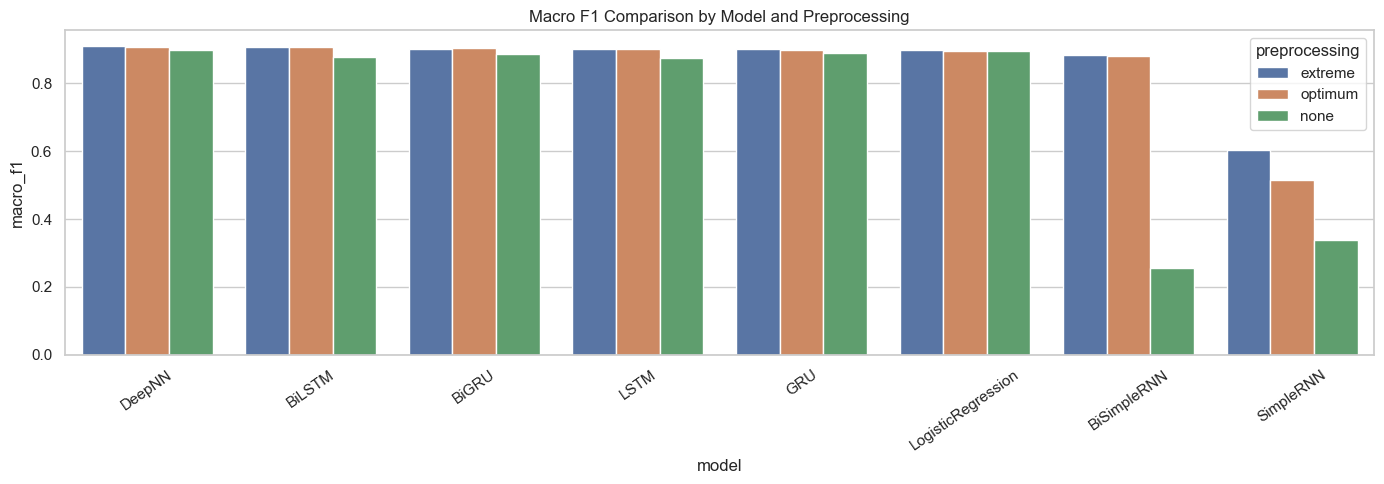

Best-performing experiment:
preprocessing      extreme
representation      TF-IDF
model               DeepNN
accuracy          0.911583
macro_f1           0.91108
Name: 0, dtype: object

Worst-performing experiment:
preprocessing            none
representation      Skip-gram
model             BiSimpleRNN
accuracy             0.336583
macro_f1             0.255161
Name: 23, dtype: object

Saved: final_results_table.csv, tuning_logs_table.csv


In [17]:
tuning_df = pd.DataFrame(tuning_logs)
results_df = pd.DataFrame(all_results)

print('Tuning log rows:', len(tuning_df))
display(tuning_df.sort_values('val_macro_f1', ascending=False).head(20))

results_df = results_df.sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(14, 5))
sns.barplot(data=results_df, x='model', y='macro_f1', hue='preprocessing')
plt.title('Macro F1 Comparison by Model and Preprocessing')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

best_exp = results_df.iloc[0]
worst_exp = results_df.iloc[-1]

print('Best-performing experiment:')
print(best_exp)

print('\nWorst-performing experiment:')
print(worst_exp)

results_df.to_csv('final_results_table.csv', index=False)
tuning_df.to_csv('tuning_logs_table.csv', index=False)
print('\nSaved: final_results_table.csv, tuning_logs_table.csv')